# TAE-IA · Módulo 6 · L12 — Vision App

## 💻💻🚗🚗 Analizador de seguridad vial 🤖 👽🤖 👽

    ** 🧑‍🏫 🧑‍🏫 Profesor:🧑‍🏫 🧑‍🏫 ** Dr. Francisco Rodríguez  
    ** 👨‍🎓👨‍🎓Estudiante:👨‍🎓👨‍🎓** Cesar Eduardo Inda Ceniceros

Esta aplicación analiza fotografías de calles o carreteras:

1. **DETR** detecta personas, vehículos, semáforos y señales.
2. **DPT-Hybrid/MiDaS** estima la cercanía relativa de cada zona.
3. El pipeline combina detección, cercanía y tamaño para asignar un nivel de riesgo:
   **BAJO, MEDIO o ALTO**.

> Esta aplicación es una demostración académica. La profundidad es relativa y no representa metros reales.



# DOCUMENTACION

https://huggingface.co/docs/transformers/model_doc/detr

https://huggingface.co/Intel/dpt-hybrid-midas


## MIDAS ARCHITECTURE

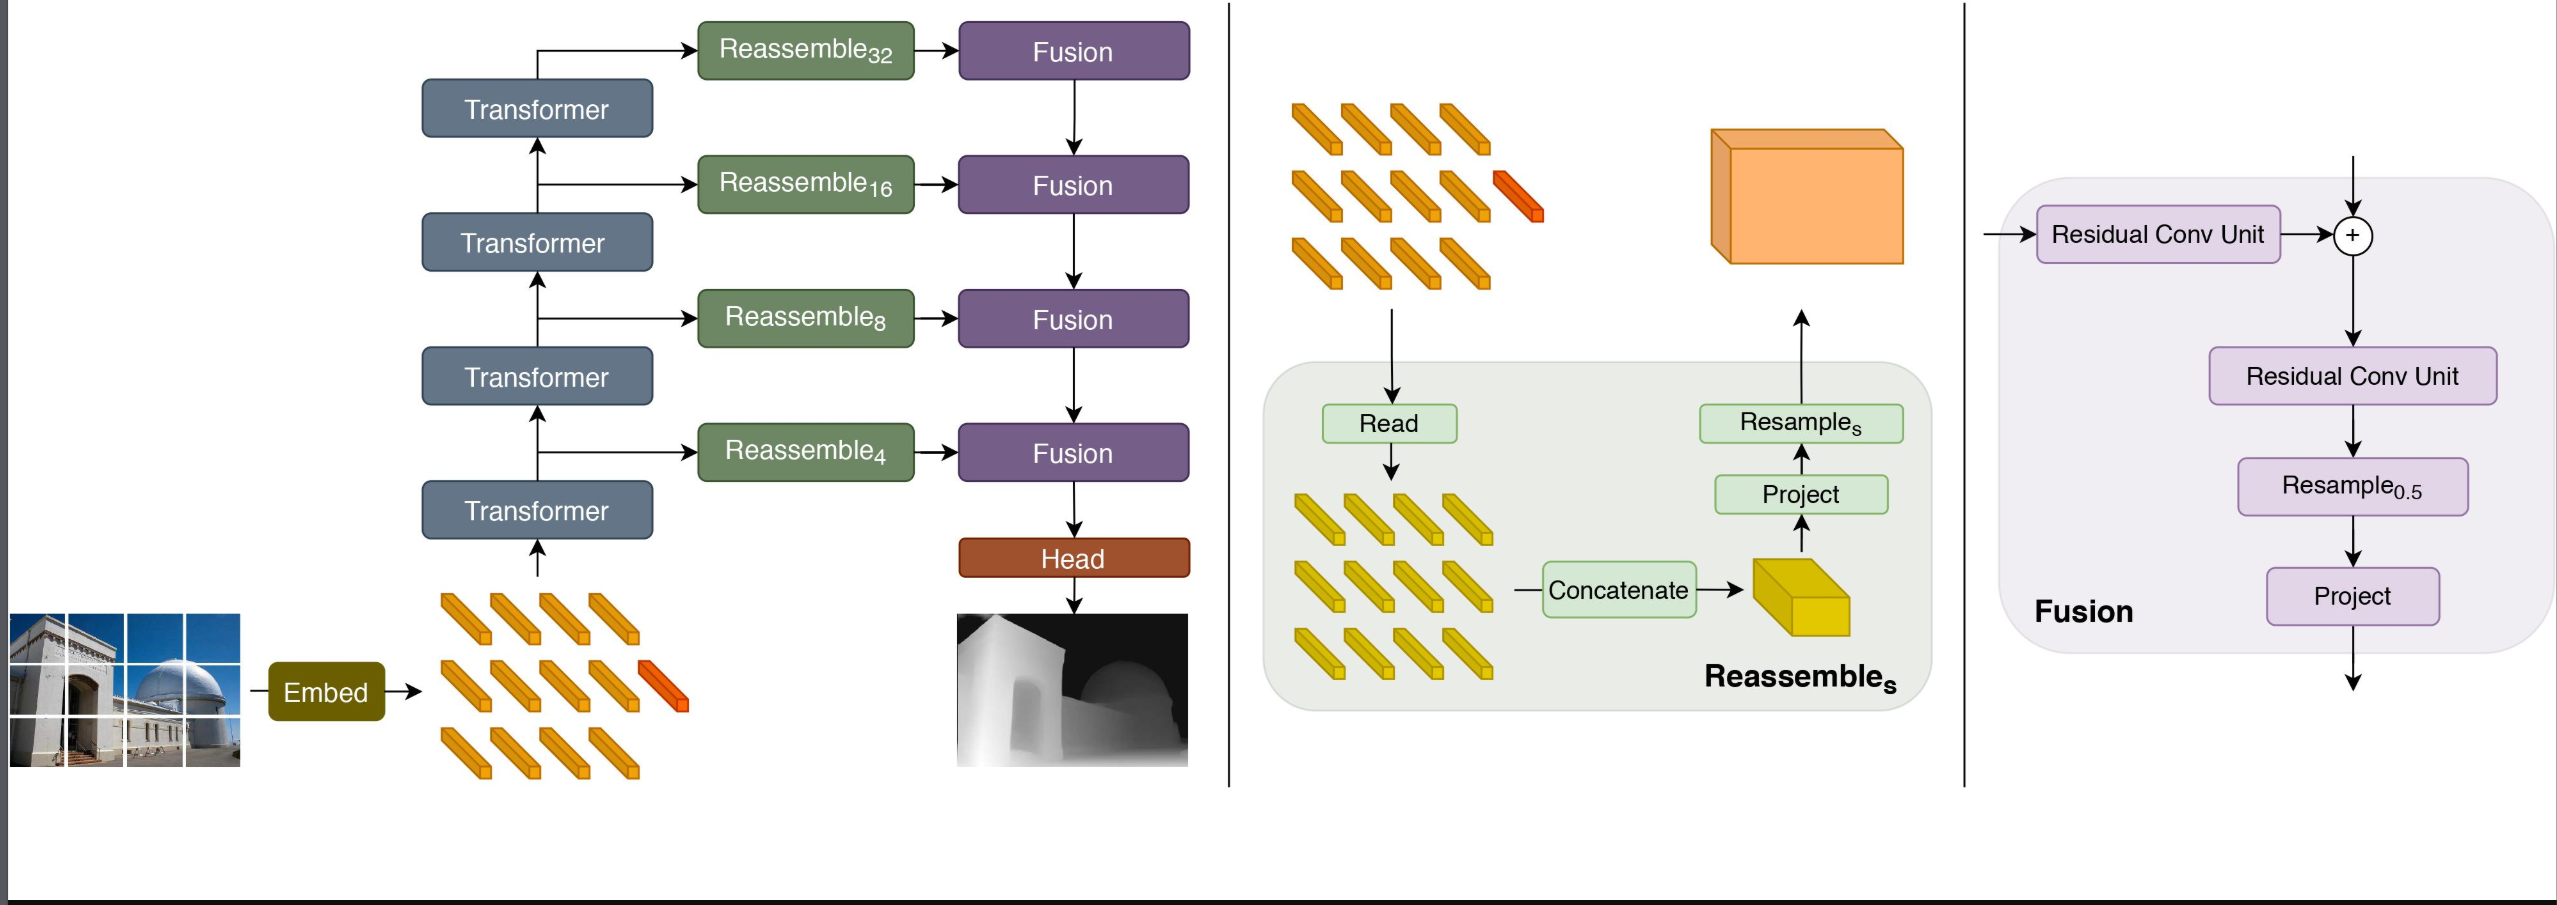

In [1]:
#! 1) INSTALAR LIBRERIAS

%pip install -q "transformers>=4.46,<6" "gradio>=4.44,<7" "timm>=1.0" accelerate safetensors

In [2]:
#! 2) CONFIGURACIÓN Y CARGAR IMAGENES

import os
import time
import random
import numpy as np
import torch

from PIL import Image, ImageDraw, ImageFont
from matplotlib import colormaps
from google.colab import drive

# ---------------------------------------------------------
# Montar Google Drive
# ---------------------------------------------------------
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
INPUT_DIR = f'{DRIVE_ROOT}/L12_road_inputs'
OUTPUT_DIR = f'{DRIVE_ROOT}/L12_road_safety_output'

# Los modelos se guardan temporalmente en el entorno de Colab.
MODEL_CACHE = '/content/models_l12'

for folder in (INPUT_DIR, OUTPUT_DIR, MODEL_CACHE):
    os.makedirs(folder, exist_ok=True)

os.environ['HF_HOME'] = MODEL_CACHE
os.environ['TORCH_HOME'] = MODEL_CACHE

# ---------------------------------------------------------
# Verificar GPU
# ---------------------------------------------------------
if not torch.cuda.is_available():
    raise SystemExit(
        'No se encontró GPU. Selecciona: '
        'Entorno de ejecución > Cambiar tipo de entorno > T4 GPU.'
    )

DEVICE = 'cuda'
DTYPE = torch.float16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def show_vram(tag=''):
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {used:.2f}/{total:.1f} GB  {tag}')

print('GPU:', torch.cuda.get_device_name(0))
print('Carpeta de entradas:', INPUT_DIR)
print('Carpeta de salidas :', OUTPUT_DIR)

show_vram('al inicio')

Mounted at /content/drive
GPU: Tesla T4
Carpeta de entradas: /content/drive/MyDrive/TAE_IA_M6/L12_road_inputs
Carpeta de salidas : /content/drive/MyDrive/TAE_IA_M6/L12_road_safety_output
VRAM: 0.00/15.6 GB  al inicio


In [3]:
#3: SUBIR FOTOGRAFIAS

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

def upload_inputs():
    """Abre el selector de archivos de Google Colab."""
    from google.colab import files

    uploaded = files.upload()

    for name, data in uploaded.items():
        safe_name = os.path.basename(name)
        path = os.path.join(INPUT_DIR, safe_name)

        with open(path, 'wb') as file:
            file.write(data)

        print('Imagen guardada:', safe_name)

def load_inputs(n=5):
    """Carga hasta cinco imágenes desde Drive."""
    names = [
        name for name in sorted(os.listdir(INPUT_DIR))
        if name.lower().endswith(IMG_EXTS)
    ][:n]

    images = {}

    for name in names:
        path = os.path.join(INPUT_DIR, name)

        try:
            with Image.open(path) as image:
                images[name] = image.convert('RGB').copy()

        except Exception as error:
            print(f'No se pudo abrir {name}: {error}')

    return images

# Si la carpeta está vacía, se abre automáticamente el selector.
if not load_inputs():
    print('Selecciona de tres a cinco fotografías de calles o carreteras.')
    upload_inputs()

images_ready = load_inputs()

print(f'\n{len(images_ready)} imágenes listas:')

for filename in images_ready:
    print(' -', filename)


5 imágenes listas:
 - calle1.jpeg
 - calle2.png
 - calle3.webp
 - carretera1.jpg
 - carretera2.jpg


In [4]:
#4 CARGAR DETR Y DPT

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    AutoModelForDepthEstimation,
)

DETECTOR_ID = 'facebook/detr-resnet-50'
#DETECTOR_ID = 'facebook/detr-resnet-50-dc5'

DEPTH_ID = 'Intel/dpt-hybrid-midas'

# ---------------------------------------------------------
# Modelo 1: DETR para detección de objetos
# ---------------------------------------------------------
print('Cargando DETR...')

detector_processor = AutoImageProcessor.from_pretrained(
    DETECTOR_ID,
    cache_dir=MODEL_CACHE
)

detector_model = AutoModelForObjectDetection.from_pretrained(
    DETECTOR_ID,
    cache_dir=MODEL_CACHE,
    torch_dtype=DTYPE
).to(DEVICE).eval()

show_vram('después de DETR')

# ---------------------------------------------------------
# Modelo 2: DPT para profundidad relativa
# ---------------------------------------------------------
print('\nCargando DPT-Hybrid...')

depth_processor = AutoImageProcessor.from_pretrained(
    DEPTH_ID,
    cache_dir=MODEL_CACHE
)

depth_model = AutoModelForDepthEstimation.from_pretrained(
    DEPTH_ID,
    cache_dir=MODEL_CACHE,
    torch_dtype=DTYPE
).to(DEVICE).eval()

show_vram('con ambos modelos')

print('\nModelos cargados correctamente.')

Cargando DETR...


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  167MB            

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  490MB            

model.safetensors: downloading bytes:           |  0.00B            

VRAM: 0.34/15.6 GB  con ambos modelos

Modelos cargados correctamente.


In [5]:
#5 ENTRADA Y FUNCIONES DE LOS MODELOS:

MAX_SIDE = 1280
MIN_SIDE = 64

# Clases de COCO que son relevantes para la aplicación.
ROAD_LABELS = {
    'person',
    'bicycle',
    'car',
    'motorcycle',
    'bus',
    'truck',
    'traffic light',
    'stop sign'
}

LABEL_ES = {
    'person': 'persona',
    'bicycle': 'bicicleta',
    'car': 'automóvil',
    'motorcycle': 'motocicleta',
    'bus': 'autobús',
    'truck': 'camión',
    'traffic light': 'semáforo',
    'stop sign': 'señal de alto'
}

def coerce_image(value):
    """
    Convierte una entrada de Gradio o Colab
    en una imagen PIL RGB válida.
    """

    if value is None:
        raise ValueError('Primero carga una imagen.')

    # Gradio puede entregar un arreglo NumPy.
    if isinstance(value, np.ndarray):
        value = np.clip(value, 0, 255).astype(np.uint8)
        value = Image.fromarray(value)

    if not isinstance(value, Image.Image):
        raise ValueError(
            'Formato no compatible. Carga una imagen JPG, PNG, WEBP o BMP.'
        )

    # Convierte imágenes en escala de grises, RGBA o CMYK a RGB.
    image = value.convert('RGB')

    width, height = image.size

    if min(width, height) < MIN_SIDE:
        raise ValueError(
            f'La imagen es demasiado pequeña ({width}x{height}). '
            f'Usa al menos {MIN_SIDE}x{MIN_SIDE} píxeles.'
        )

    # Reducir imágenes demasiado grandes.
    if max(width, height) > MAX_SIDE:
        scale = MAX_SIDE / max(width, height)

        new_size = (
            round(width * scale),
            round(height * scale)
        )

        image = image.resize(
            new_size,
            Image.Resampling.LANCZOS
        )

    return image

def move_batch_to_gpu(batch):
    """
    Mueve los tensores a la GPU.
    Los tensores decimales se convierten a float16.
    """

    moved = {}

    for key, value in batch.items():
        if torch.is_floating_point(value):
            moved[key] = value.to(
                device=DEVICE,
                dtype=DTYPE
            )
        else:
            moved[key] = value.to(device=DEVICE)

    return moved

def detect_road_objects(image, threshold=0.60, max_objects=12):
    """
    Ejecuta DETR y devuelve una lista de objetos viales.
    """

    batch = detector_processor(
        images=image,
        return_tensors='pt'
    )

    batch = move_batch_to_gpu(batch)

    with torch.inference_mode():
        outputs = detector_model(**batch)

    target_sizes = torch.tensor(
        [[image.height, image.width]],
        device=outputs.logits.device
    )

    result = detector_processor.post_process_object_detection(
        outputs,
        threshold=float(threshold),
        target_sizes=target_sizes
    )[0]

    detections = []

    for score, class_id, box in zip(
        result['scores'],
        result['labels'],
        result['boxes']
    ):
        class_id = int(class_id.item())
        label = detector_model.config.id2label[class_id]

        # Ignorar clases que no son importantes para esta aplicación.
        if label not in ROAD_LABELS:
            continue

        x1, y1, x2, y2 = [
            int(round(value))
            for value in box.tolist()
        ]

        # Mantener la caja dentro de la imagen.
        x1 = max(0, min(image.width - 1, x1))
        y1 = max(0, min(image.height - 1, y1))
        x2 = max(x1 + 1, min(image.width, x2))
        y2 = max(y1 + 1, min(image.height, y2))

        detections.append({
            'label': label,
            'confidence': float(score.item()),
            'box': (x1, y1, x2, y2)
        })

    detections.sort(
        key=lambda item: item['confidence'],
        reverse=True
    )

    return detections[:int(max_objects)]

def estimate_proximity(image):
    """
    Ejecuta DPT y genera:
    1. Una matriz de cercanía normalizada.
    2. Una imagen de calor.
    """

    batch = depth_processor(
        images=image,
        return_tensors='pt'
    )

    batch = move_batch_to_gpu(batch)

    with torch.inference_mode():
        predicted_depth = depth_model(
            **batch
        ).predicted_depth

    # Ajustar la salida al tamaño de la fotografía original.
    resized_depth = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=(image.height, image.width),
        mode='bicubic',
        align_corners=False
    ).squeeze()

    raw_depth = resized_depth.float().cpu().numpy()

    # Normalización robusta usando percentiles.
    low, high = np.percentile(raw_depth, (2, 98))

    if high <= low:
        proximity = np.zeros_like(
            raw_depth,
            dtype=np.float32
        )
    else:
        proximity = np.clip(
            (raw_depth - low) / (high - low),
            0,
            1
        ).astype(np.float32)

    # Colores oscuros = lejos; colores claros = cerca.
    heat_rgb = (
        colormaps['magma'](proximity)[..., :3] * 255
    ).astype(np.uint8)

    heat_image = Image.fromarray(heat_rgb)

    return proximity, heat_image

In [6]:
#6 PIPELINES COMBINADO

# Prioridad de cada tipo de objeto.
TYPE_PRIORITY = {
    'person': 1.00,
    'bicycle': 0.90,
    'motorcycle': 0.90,
    'car': 0.70,
    'bus': 0.65,
    'truck': 0.75,
    'traffic light': 0.30,
    'stop sign': 0.30
}

LEVEL_COLORS = {
    'ALTO': (220, 38, 38),
    'MEDIO': (245, 158, 11),
    'BAJO': (22, 163, 74)
}

LEVEL_ICONS = {
    'ALTO': '🔴',
    'MEDIO': '🟠',
    'BAJO': '🟢'
}

def score_detections(image, detections, proximity):
    """
    Combina:
    65 % cercanía
    25 % tamaño
    10 % tipo de objeto
    """

    image_area = image.width * image.height
    evaluated = []

    for item in detections:
        x1, y1, x2, y2 = item['box']

        # Usar principalmente la zona central de la caja.
        margin_x = max(1, int((x2 - x1) * 0.15))
        margin_y = max(1, int((y2 - y1) * 0.15))

        start_x = min(x2 - 1, x1 + margin_x)
        end_x = max(x1 + 1, x2 - margin_x)

        start_y = min(y2 - 1, y1 + margin_y)
        end_y = max(y1 + 1, y2 - margin_y)

        region = proximity[
            start_y:end_y,
            start_x:end_x
        ]

        if region.size:
            closeness = float(np.median(region))
        else:
            closeness = 0.0

        box_area = max(
            1,
            (x2 - x1) * (y2 - y1)
        )

        area_ratio = box_area / image_area

        # Aumenta con el tamaño de la caja.
        size_score = min(
            1.0,
            2.5 * np.sqrt(area_ratio)
        )

        type_score = TYPE_PRIORITY.get(
            item['label'],
            0.50
        )

        risk = float(np.clip(
            0.65 * closeness
            + 0.25 * size_score
            + 0.10 * type_score,
            0,
            1
        ))

        if risk >= 0.67:
            level = 'ALTO'
        elif risk >= 0.40:
            level = 'MEDIO'
        else:
            level = 'BAJO'

        evaluated.append({
            **item,
            'closeness': closeness,
            'area_ratio': area_ratio,
            'risk': risk,
            'level': level
        })

    evaluated.sort(
        key=lambda item: item['risk'],
        reverse=True
    )

    return evaluated

def draw_results(image, evaluated):
    """Dibuja las cajas y niveles sobre la imagen."""

    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()

    line_width = max(
        2,
        round(max(image.size) / 320)
    )

    for item in evaluated:
        x1, y1, x2, y2 = item['box']
        color = LEVEL_COLORS[item['level']]

        label_text = (
            f"{LABEL_ES[item['label']]} | "
            f"{item['level']} {item['risk']:.2f} | "
            f"conf {item['confidence']:.2f}"
        )

        draw.rectangle(
            (x1, y1, x2, y2),
            outline=color,
            width=line_width
        )

        left, top, right, bottom = draw.textbbox(
            (0, 0),
            label_text,
            font=font
        )

        text_width = right - left
        text_height = bottom - top
        text_y = max(0, y1 - text_height - 8)

        draw.rectangle(
            (
                x1,
                text_y,
                min(image.width, x1 + text_width + 8),
                text_y + text_height + 8
            ),
            fill=color
        )

        draw.text(
            (x1 + 4, text_y + 4),
            label_text,
            fill='white',
            font=font
        )

    return canvas

def build_report(evaluated, timings, threshold):
    """Construye el reporte Markdown."""

    lines = [
        '### Resultado del análisis',
        f"- Umbral de detección: **{threshold:.2f}**",
        (
            f"- Tiempo: DETR **{timings['detr']:.2f} s**, "
            f"DPT **{timings['dpt']:.2f} s**, "
            f"total **{timings['total']:.2f} s**"
        ),
        ''
    ]

    if not evaluated:
        lines.extend([
            'No se detectaron objetos viales por encima del umbral.',
            '',
            'Puedes reducir el umbral o probar otra fotografía.'
        ])

        return '\n'.join(lines)

    lines.extend([
        '| # | Objeto | Confianza | Cercanía | Riesgo | Nivel |',
        '|---:|---|---:|---:|---:|---|'
    ])

    for index, item in enumerate(evaluated, start=1):
        icon = LEVEL_ICONS[item['level']]

        lines.append(
            f"| {index} "
            f"| {LABEL_ES[item['label']]} "
            f"| {item['confidence']:.2f} "
            f"| {item['closeness']:.2f} "
            f"| {item['risk']:.2f} "
            f"| {icon} {item['level']} |"
        )

    lines.extend([
        '',
        '> La cercanía es relativa dentro de la imagen; no representa metros.'
    ])

    return '\n'.join(lines)

def run_pipeline(value, threshold=0.60, max_objects=12):
    """
    Pipeline completo:
    entrada -> DETR -> DPT -> riesgo -> visualización.
    """

    total_start = time.perf_counter()

    try:
        image = coerce_image(value)

    except ValueError as error:
        return (
            None,
            None,
            f'### Entrada no válida\n{error}'
        )

    try:
        # Etapa 1: detección.
        stage_start = time.perf_counter()

        detections = detect_road_objects(
            image,
            threshold=threshold,
            max_objects=max_objects
        )

        detr_time = time.perf_counter() - stage_start

        # Etapa 2: profundidad relativa.
        stage_start = time.perf_counter()

        proximity, heat_image = estimate_proximity(image)

        dpt_time = time.perf_counter() - stage_start

        # Etapa 3: combinar resultados.
        evaluated = score_detections(
            image,
            detections,
            proximity
        )

        annotated = draw_results(
            image,
            evaluated
        )

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()

        return (
            None,
            None,
            '### Memoria insuficiente\nPrueba otra imagen o reinicia el entorno.'
        )

    except Exception as error:
        print(
            f'[run_pipeline] '
            f'{type(error).__name__}: {error}'
        )

        return (
            None,
            None,
            '### Error de procesamiento\nRevisa la salida de Colab.'
        )

    timings = {
        'detr': detr_time,
        'dpt': dpt_time,
        'total': time.perf_counter() - total_start
    }

    report = build_report(
        evaluated,
        timings,
        float(threshold)
    )

    return annotated, heat_image, report

In [7]:
#! 7) PROBAR Y GUARDAR RESULTADOS:

print('--- PRUEBAS DEL CONTRATO DE ENTRADA ---')

test_cases = [
    ('None', None),
    (
        'NumPy',
        np.zeros((80, 120, 3), dtype=np.uint8)
    ),
    (
        'Escala de grises',
        Image.new('L', (120, 80), 128)
    ),
    (
        'RGBA',
        Image.new('RGBA', (120, 80), (20, 40, 80, 120))
    ),
    (
        'Muy pequeña',
        Image.new('RGB', (20, 20), 'white')
    ),
    (
        'Muy grande',
        Image.new('RGB', (4000, 3000), 'white')
    )
]

for name, value in test_cases:
    try:
        normalized = coerce_image(value)

        print(
            f'{name:18s} -> '
            f'OK: RGB {normalized.size}'
        )

    except ValueError as error:
        print(
            f'{name:18s} -> '
            f'CONTROLADO: {error}'
        )

print('\n--- PRUEBA COMPLETA DEL PIPELINE ---')

test_images = load_inputs(n=5)

if not test_images:
    print(
        'No hay imágenes. Regresa a la celda 4 '
        'y ejecuta upload_inputs().'
    )

else:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    for index, (name, image) in enumerate(
        test_images.items(),
        start=1
    ):
        print(f'\nProcesando {index}: {name}')

        annotated, heat, report = run_pipeline(
            image,
            threshold=0.60,
            max_objects=12
        )

        print(report)

        # Guardar los resultados de cada imagen.
        if annotated is not None:
            base_name = os.path.splitext(name)[0]

            annotated_path = os.path.join(
                OUTPUT_DIR,
                f'{base_name}_analizada.jpg'
            )

            heat_path = os.path.join(
                OUTPUT_DIR,
                f'{base_name}_cercania.jpg'
            )

            annotated.save(
                annotated_path,
                quality=95
            )

            heat.save(
                heat_path,
                quality=95
            )

            print('Imagen anotada:', annotated_path)
            print('Mapa guardado :', heat_path)

    peak = torch.cuda.max_memory_allocated() / 1e9
    total = (
        torch.cuda
        .get_device_properties(0)
        .total_memory / 1e9
    )

    print(
        f'\nPico de VRAM: '
        f'{peak:.2f} GB de {total:.1f} GB'
    )

--- PRUEBAS DEL CONTRATO DE ENTRADA ---
None               -> CONTROLADO: Primero carga una imagen.
NumPy              -> OK: RGB (120, 80)
Escala de grises   -> OK: RGB (120, 80)
RGBA               -> OK: RGB (120, 80)
Muy pequeña        -> CONTROLADO: La imagen es demasiado pequeña (20x20). Usa al menos 64x64 píxeles.
Muy grande         -> OK: RGB (1280, 960)

--- PRUEBA COMPLETA DEL PIPELINE ---

Procesando 1: calle1.jpeg
### Resultado del análisis
- Umbral de detección: **0.60**
- Tiempo: DETR **2.00 s**, DPT **0.50 s**, total **2.51 s**

| # | Objeto | Confianza | Cercanía | Riesgo | Nivel |
|---:|---|---:|---:|---:|---|
| 1 | automóvil | 1.00 | 0.85 | 0.87 | 🔴 ALTO |
| 2 | automóvil | 1.00 | 0.27 | 0.42 | 🟠 MEDIO |
| 3 | motocicleta | 1.00 | 0.27 | 0.40 | 🟢 BAJO |
| 4 | persona | 1.00 | 0.30 | 0.39 | 🟢 BAJO |
| 5 | persona | 1.00 | 0.25 | 0.36 | 🟢 BAJO |
| 6 | persona | 0.97 | 0.22 | 0.29 | 🟢 BAJO |
| 7 | persona | 0.99 | 0.16 | 0.25 | 🟢 BAJO |
| 8 | persona | 0.97 | 0.18 | 0.25 

In [8]:
#! 8) INTERFAZ -- GRADIO

import gradio as gr

def predict(
    image,
    threshold,
    max_objects,
    progress=gr.Progress()
):
    if image is None:
        return (
            None,
            None,
            '### Falta la imagen\nCarga una fotografía primero.'
        )

    progress(
        0.10,
        desc='Validando imagen...'
    )

    progress(
        0.35,
        desc='Ejecutando DETR y DPT...'
    )

    result = run_pipeline(
        image,
        threshold=float(threshold),
        max_objects=int(max_objects)
    )

    progress(
        1.0,
        desc='Análisis terminado'
    )

    return result

# Crear ejemplos con las imágenes de Drive.
example_paths = [
    [os.path.join(INPUT_DIR, filename)]
    for filename in load_inputs(n=5)
]

with gr.Blocks(
    title='Radar Visual — Seguridad vial'
) as app:

    gr.Markdown(
        '# 🚦 Radar Visual\n'
        '## Analizador de seguridad vial\n\n'
        'DETR localiza objetos y DPT estima '
        'su cercanía relativa.'
    )

    with gr.Row():

        with gr.Column(scale=1):

            input_image = gr.Image(
                type='pil',
                label='Fotografía de entrada'
            )

            threshold = gr.Slider(
                minimum=0.10,
                maximum=0.95,
                value=0.60,
                step=0.05,
                label='Confianza mínima de DETR'
            )

            max_objects = gr.Slider(
                minimum=1,
                maximum=20,
                value=12,
                step=1,
                label='Máximo de objetos'
            )

            with gr.Row():
                analyze_button = gr.Button(
                    'Analizar escena',
                    variant='primary'
                )

                clear_button = gr.Button(
                    'Limpiar'
                )

            if example_paths:
                gr.Examples(
                    examples=example_paths,
                    inputs=input_image
                )

        with gr.Column(scale=2):

            with gr.Row():

                annotated_output = gr.Image(
                    label='Objetos y nivel estimado'
                )

                depth_output = gr.Image(
                    label='Mapa de cercanía'
                )

            report_output = gr.Markdown(
                'Carga una imagen y presiona '
                '**Analizar escena**.'
            )

    analyze_button.click(
        fn=predict,
        inputs=[
            input_image,
            threshold,
            max_objects
        ],
        outputs=[
            annotated_output,
            depth_output,
            report_output
        ]
    )

    clear_button.click(
        fn=lambda: (
            None,
            None,
            None,
            'Carga una imagen y presiona **Analizar escena**.'
        ),
        inputs=None,
        outputs=[
            input_image,
            annotated_output,
            depth_output,
            report_output
        ]
    )

# Solo se procesa una solicitud a la vez para proteger la GPU.
app.queue(
    default_concurrency_limit=1
).launch(
    share=True,
    quiet=True
)

* Running on public URL: https://52e9981ac3f3349b59.gradio.live


In [9]:
#! 9) EXPERIMENTO CON DIFERENTES UMBRALES

experiment_images = load_inputs(n=1)

if not experiment_images:
    print(
        'Sube al menos una imagen para '
        'realizar el experimento.'
    )

else:
    name, image = next(
        iter(experiment_images.items())
    )

    image = coerce_image(image)

    print('Imagen seleccionada:', name)

    for threshold_value in (0.30, 0.60, 0.85):

        start = time.perf_counter()

        detections = detect_road_objects(
            image,
            threshold=threshold_value,
            max_objects=20
        )

        elapsed = time.perf_counter() - start

        summary = ', '.join(
            f"{LABEL_ES[item['label']]} "
            f"{item['confidence']:.2f}"
            for item in detections
        )

        if not summary:
            summary = 'ningún objeto vial'

        print(
            f'\nUmbral: {threshold_value:.2f}'
        )

        print(
            f'Detecciones: {len(detections)}'
        )

        print(
            f'Tiempo: {elapsed:.2f} segundos'
        )

        print(
            'Objetos:', summary
        )

Imagen seleccionada: calle1.jpeg

Umbral: 0.30
Detecciones: 20
Tiempo: 0.08 segundos
Objetos: persona 1.00, persona 1.00, motocicleta 1.00, automóvil 1.00, automóvil 1.00, automóvil 1.00, persona 0.99, automóvil 0.99, persona 0.97, persona 0.97, persona 0.97, persona 0.96, persona 0.95, persona 0.95, persona 0.94, persona 0.94, persona 0.93, bicicleta 0.91, bicicleta 0.90, persona 0.88

Umbral: 0.60
Detecciones: 20
Tiempo: 0.07 segundos
Objetos: persona 1.00, persona 1.00, motocicleta 1.00, automóvil 1.00, automóvil 1.00, automóvil 1.00, persona 0.99, automóvil 0.99, persona 0.97, persona 0.97, persona 0.97, persona 0.96, persona 0.95, persona 0.95, persona 0.94, persona 0.94, persona 0.93, bicicleta 0.91, bicicleta 0.90, persona 0.88

Umbral: 0.85
Detecciones: 20
Tiempo: 0.07 segundos
Objetos: persona 1.00, persona 1.00, motocicleta 1.00, automóvil 1.00, automóvil 1.00, automóvil 1.00, persona 0.99, automóvil 0.99, persona 0.97, persona 0.97, persona 0.97, persona 0.96, persona 0.95, 

In [ ]:
#! 10) LIMPIEZA PARA MODELOS ANTERIORES:

import shutil

LEGACY = f'{DRIVE_ROOT}/models'

def folder_gb(path):
    total_bytes = 0

    for directory, _, files in os.walk(path):
        for filename in files:
            file_path = os.path.join(
                directory,
                filename
            )

            try:
                total_bytes += os.path.getsize(
                    file_path
                )
            except OSError:
                pass

    return total_bytes / 1e9

if os.path.exists(LEGACY):

    print(
        f'{LEGACY}: '
        f'{folder_gb(LEGACY):.2f} GB'
    )

    for entry in sorted(os.listdir(LEGACY)):
        entry_path = os.path.join(
            LEGACY,
            entry
        )

        print(
            f'{folder_gb(entry_path):6.2f} GB  '
            f'{entry}'
        )

    # Cambiar a True únicamente después de revisar la lista.
    CONFIRM = False

    if CONFIRM:
        freed = folder_gb(LEGACY)
        shutil.rmtree(LEGACY)

        print(
            f'Se liberaron {freed:.2f} GB.'
        )

    else:
        print(
            '\nNo se eliminó nada. '
            'Cambia CONFIRM=True solo si deseas borrar '
            'los modelos anteriores.'
        )

else:
    print(
        'No se encontró una carpeta antigua de modelos.'
    )

print(
    'Entradas L12 conservadas:',
    os.path.exists(INPUT_DIR)
)

print(
    'Resultados L12 conservados:',
    os.path.exists(OUTPUT_DIR)
)

#todo: "https://huggingface.co/docs/transformers/model_doc/depth_anything"